# 📘 Chapter 1: The Machine Learning Landscape
### *Hands-On ML with Scikit-Learn, Keras & TensorFlow — Aurélien Géron*

---

> **How to use this notebook**  
> 🟦 Blue boxes = key definitions  |  🟨 Yellow boxes = important takeaways  |  💡 = tips  |  🧪 = code experiments

---


## 1. 🤖 What is Machine Learning?

**Traditional programming** says: *"Here are the rules → apply them to data → get answers."*

**Machine Learning** says: *"Here is data + answers → figure out the rules yourself."*

> 🟦 **Definition (Arthur Samuel, 1959):**  
> *"Machine Learning is the field of study that gives computers the ability to learn without being explicitly programmed."*

### The classic example: Spam filter

| Approach | How it works |
|---|---|
| **Traditional** | You write rules: if email contains "FREE MONEY" → spam |
| **ML** | You show 10,000 labelled emails → the model learns the patterns |

The ML approach is *much* better because:
- Spammers change their tactics → rules go stale
- ML model can be re-trained automatically on new data
- Some patterns are too complex for humans to write rules for


C:\Users\User\AppData\Local\Temp\ipykernel_3140\368745271.py:49: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3140\368745271.py:49: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3140\368745271.py:49: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3140\368745271.py:49: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3140\368745271.py:50: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("01_traditional_vs_ml.png", dpi=150, bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_3140\368745271.py:50: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) m

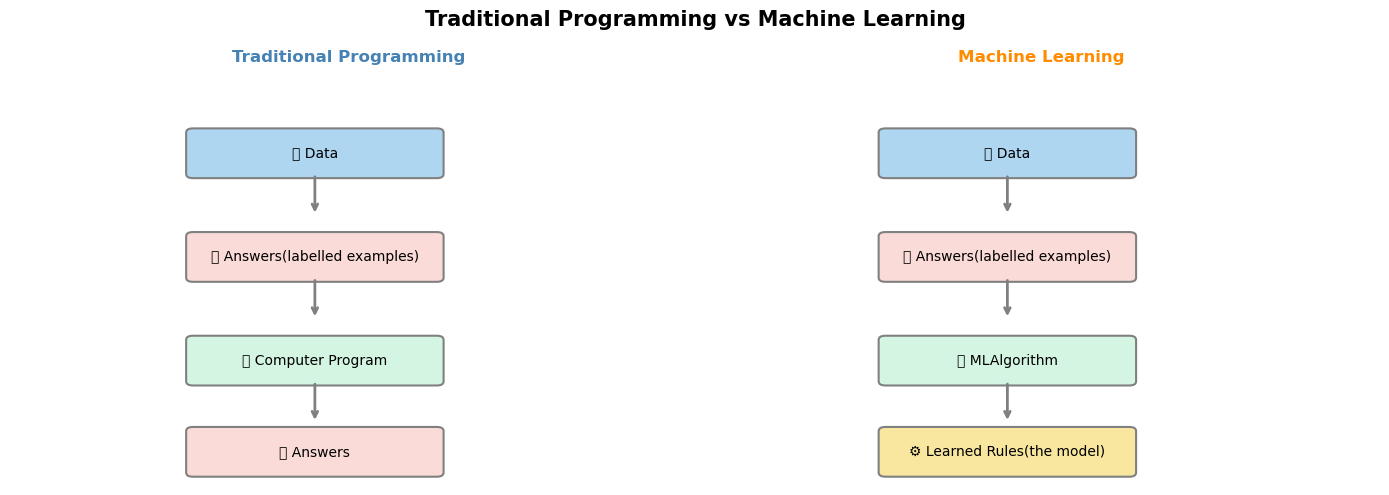

✅ Notice: In ML, the RULES are the OUTPUT, not the input!


In [9]:
# Let's visualise the difference visually
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Traditional Programming vs Machine Learning", fontsize=15, fontweight='bold')

# --- Left: Traditional ---
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title("Traditional Programming", fontsize=12, color='steelblue', fontweight='bold')

boxes = [
    (4.5, 8, "📊 Data", "#AED6F1"),
    (4.5, 5.5, "✅ Answers(labelled examples)", "#FADBD8"),
    (4.5, 3, "💻 Computer Program", "#D5F5E3"),
    (4.5, 0.8, "✅ Answers", "#FADBD8"),
]
for x, y, label, color in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((x-1.8, y-0.5), 3.6, 1,
                 boxstyle="round,pad=0.1", fc=color, ec='gray', lw=1.5))
    ax.text(x, y, label, ha='center', va='center', fontsize=10)

for y_from, y_to in [(7.5, 6.5), (5.0, 4.0), (2.5, 1.5)]:
    ax.annotate("", xy=(4.5, y_to), xytext=(4.5, y_from),
                arrowprops=dict(arrowstyle="->", color='gray', lw=2))

# --- Right: Machine Learning ---
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title("Machine Learning", fontsize=12, color='darkorange', fontweight='bold')

boxes = [
    (4.5, 8, "📊 Data", "#AED6F1"),
    (4.5, 5.5, "✅ Answers(labelled examples)", "#FADBD8"),
    (4.5, 3, "🤖 MLAlgorithm", "#D5F5E3"),
    (4.5, 0.8, "⚙️ Learned Rules(the model)", "#F9E79F"),
]
for x, y, label, color in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((x-1.8, y-0.5), 3.6, 1,
                 boxstyle="round,pad=0.1", fc=color, ec='gray', lw=1.5))
    ax.text(x, y, label, ha='center', va='center', fontsize=10)

for y_from, y_to in [(7.5, 6.5), (5.0, 4.0), (2.5, 1.5)]:
    ax.annotate("", xy=(4.5, y_to), xytext=(4.5, y_from),
                arrowprops=dict(arrowstyle="->", color='gray', lw=2))

plt.tight_layout()
plt.savefig("01_traditional_vs_ml.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Notice: In ML, the RULES are the OUTPUT, not the input!")


## 2. 💡 Why Use Machine Learning?

Use ML when:

| ✅ Good use case | ❌ Bad use case |
|---|---|
| Problems with no clean rules (e.g. recognising speech) | Simple rule-based logic (e.g. tax calculation) |
| Too many rules to maintain | You have <100 data points |
| Data changes frequently (e.g. fraud detection) | You need 100% explainability |
| Finding hidden patterns in huge datasets | Real-time systems with no latency budget |

> 🟨 **Key Takeaway:** ML shines when the problem is **complex**, **data is abundant**, and **patterns change over time**.


## 3. 🗂️ Types of Machine Learning Systems

Machine Learning systems are classified by:
1. **Supervision during training** → Supervised / Unsupervised / Semi-supervised / Reinforcement
2. **Learning on-the-fly** → Online vs Batch learning
3. **How they generalise** → Instance-based vs Model-based

---

### 3.1 Supervised Learning 👩‍🏫

> 🟦 **Definition:** The training data you feed the algorithm **includes the desired solutions** (called *labels* or *targets*).

**Analogy:** Like a student learning from an answer key. Each question (input) has a correct answer (label) to learn from.

**The two main tasks:**

| Task | What it predicts | Example |
|---|---|---|
| **Classification** | A category / class | Is this email spam? (Yes/No) |
| **Regression** | A number | What will house prices be next month? |

**Common algorithms:** Linear Regression, Logistic Regression, Decision Trees, Random Forests, Support Vector Machines (SVM), Neural Networks


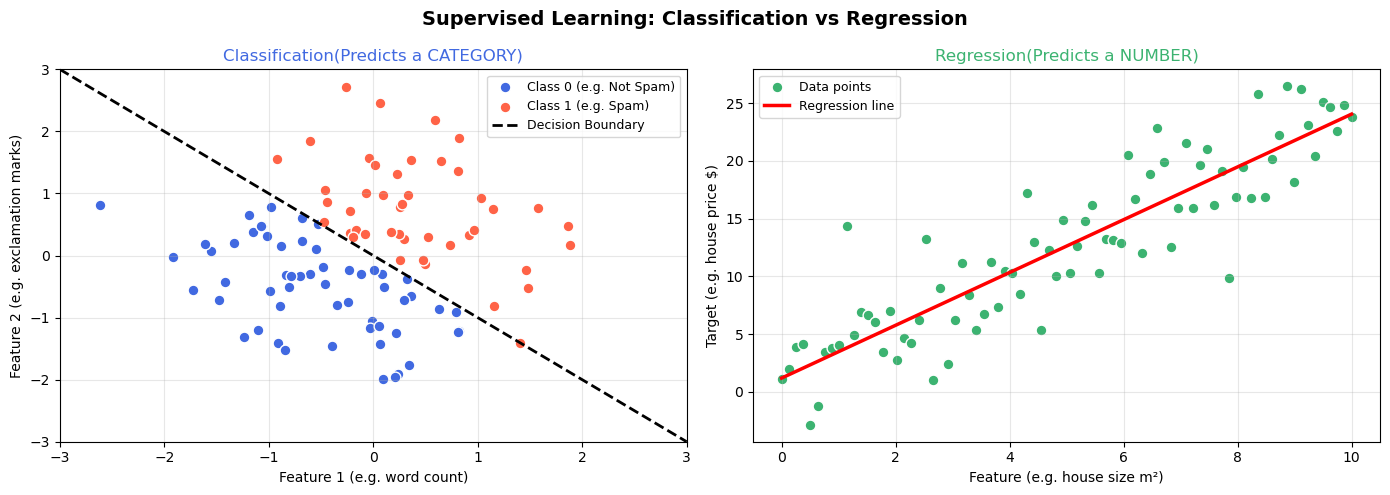

🔑 Key: Classification → discrete labels | Regression → continuous numbers


In [10]:
# VISUAL: Supervised Learning - Classification vs Regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification, make_regression
from sklearn.linear_model import LogisticRegression, LinearRegression

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Supervised Learning: Classification vs Regression", fontsize=14, fontweight='bold')

# ---- Classification ----
np.random.seed(42)
X_cls = np.random.randn(100, 2)
y_cls = (X_cls[:, 0] + X_cls[:, 1] > 0).astype(int)

ax = axes[0]
ax.scatter(X_cls[y_cls==0, 0], X_cls[y_cls==0, 1], c='royalblue', 
           label='Class 0 (e.g. Not Spam)', edgecolors='white', s=60)
ax.scatter(X_cls[y_cls==1, 0], X_cls[y_cls==1, 1], c='tomato', 
           label='Class 1 (e.g. Spam)', edgecolors='white', s=60)

# Decision boundary
xx = np.linspace(-3, 3, 100)
ax.plot(xx, -xx, 'k--', lw=2, label='Decision Boundary')
ax.set_title("Classification(Predicts a CATEGORY)", fontsize=12, color='royalblue')
ax.set_xlabel("Feature 1 (e.g. word count)")
ax.set_ylabel("Feature 2 (e.g. exclamation marks)")
ax.legend(fontsize=9)
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.grid(True, alpha=0.3)

# ---- Regression ----
X_reg = np.linspace(0, 10, 80).reshape(-1, 1)
y_reg = 2.5 * X_reg.ravel() + np.random.randn(80) * 3

model = LinearRegression().fit(X_reg, y_reg)
y_pred = model.predict(X_reg)

ax = axes[1]
ax.scatter(X_reg, y_reg, c='mediumseagreen', edgecolors='white', s=60, label='Data points')
ax.plot(X_reg, y_pred, 'r-', lw=2.5, label=f'Regression line')
ax.set_title("Regression(Predicts a NUMBER)", fontsize=12, color='mediumseagreen')
ax.set_xlabel("Feature (e.g. house size m²)")
ax.set_ylabel("Target (e.g. house price $)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("02_classification_vs_regression.png", dpi=150, bbox_inches='tight')
plt.show()
print("🔑 Key: Classification → discrete labels | Regression → continuous numbers")


### 3.2 Unsupervised Learning 🕵️

> 🟦 **Definition:** The training data is **unlabelled**. The algorithm tries to find structure on its own — no answer key!

**Analogy:** Like organising a pile of clothes without being told how — you naturally group by colour, type, etc.

**Main tasks:**
- **Clustering** → Group similar data (e.g. customer segments)  
- **Dimensionality Reduction** → Compress data, remove noise  
- **Anomaly Detection** → Find unusual data points (e.g. fraud)  
- **Association Rule Learning** → Find things that go together (e.g. "people who buy X also buy Y")

**Common algorithms:** K-Means, DBSCAN, PCA, Autoencoders


c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


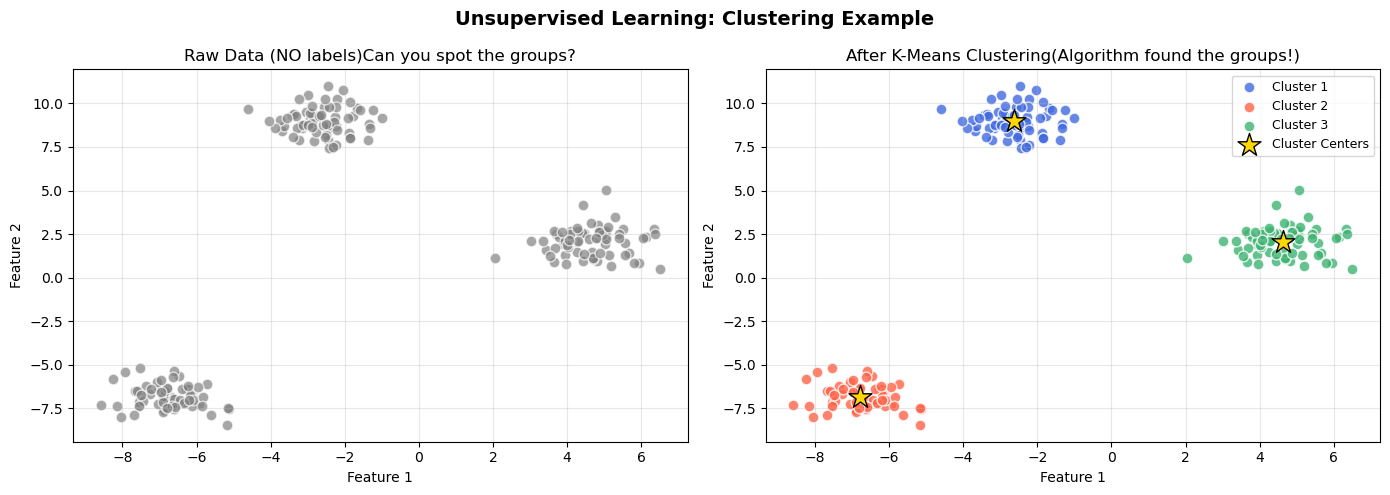

🔑 Key: No labels needed! The algorithm discovered the natural groups.


In [11]:
# VISUAL: Unsupervised Learning - Clustering
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Unsupervised Learning: Clustering Example", fontsize=14, fontweight='bold')

# Raw data (no labels)
X, _ = make_blobs(n_samples=200, centers=3, cluster_std=0.8, random_state=42)

ax = axes[0]
ax.scatter(X[:, 0], X[:, 1], c='gray', edgecolors='white', s=60, alpha=0.7)
ax.set_title("Raw Data (NO labels)Can you spot the groups?", fontsize=12)
ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
ax.grid(True, alpha=0.3)

# After clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

colors = ['royalblue', 'tomato', 'mediumseagreen']
ax = axes[1]
for i, color in enumerate(colors):
    mask = labels == i
    ax.scatter(X[mask, 0], X[mask, 1], c=color, edgecolors='white', 
               s=60, alpha=0.8, label=f'Cluster {i+1}')
ax.scatter(centers[:, 0], centers[:, 1], marker='*', s=300, 
           c='gold', edgecolors='black', zorder=5, label='Cluster Centers')
ax.set_title("After K-Means Clustering(Algorithm found the groups!)", fontsize=12)
ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("03_clustering.png", dpi=150, bbox_inches='tight')
plt.show()
print("🔑 Key: No labels needed! The algorithm discovered the natural groups.")


### 3.3 Semi-Supervised Learning

> 🟦 **Definition:** Mix of **labelled + unlabelled** data. Usually a small amount of labelled + a large amount of unlabelled.

**Real-world example:** Google Photos — you label a few photos of your friend, and it identifies them in ALL other photos.

**Why it's useful:** Labelling data is expensive and time-consuming. Semi-supervised lets you leverage huge unlabelled datasets cheaply.

---

### 3.4 Reinforcement Learning 🎮

> 🟦 **Definition:** An **agent** learns by interacting with an **environment**, receiving **rewards** (or penalties) for actions.

**Analogy:** Training a dog — good behaviour gets a treat, bad behaviour gets a "no". Over time, it learns to maximise treats.

**Famous examples:**
- DeepMind's AlphaGo beating the world Go champion
- OpenAI's robots learning to walk  
- Self-driving car simulations

| Component | What it is |
|---|---|
| **Agent** | The learner / decision maker (e.g. the robot) |
| **Environment** | The world the agent operates in |
| **Action** | What the agent can do |
| **Reward** | Feedback signal (positive or negative) |
| **Policy** | The strategy the agent learns |


C:\Users\User\AppData\Local\Temp\ipykernel_3140\516217734.py:69: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3140\516217734.py:69: UserWarning: Glyph 128105 (\N{WOMAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3140\516217734.py:69: UserWarning: Glyph 127979 (\N{SCHOOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3140\516217734.py:69: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3140\516217734.py:69: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3140\516217734.py:69: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users

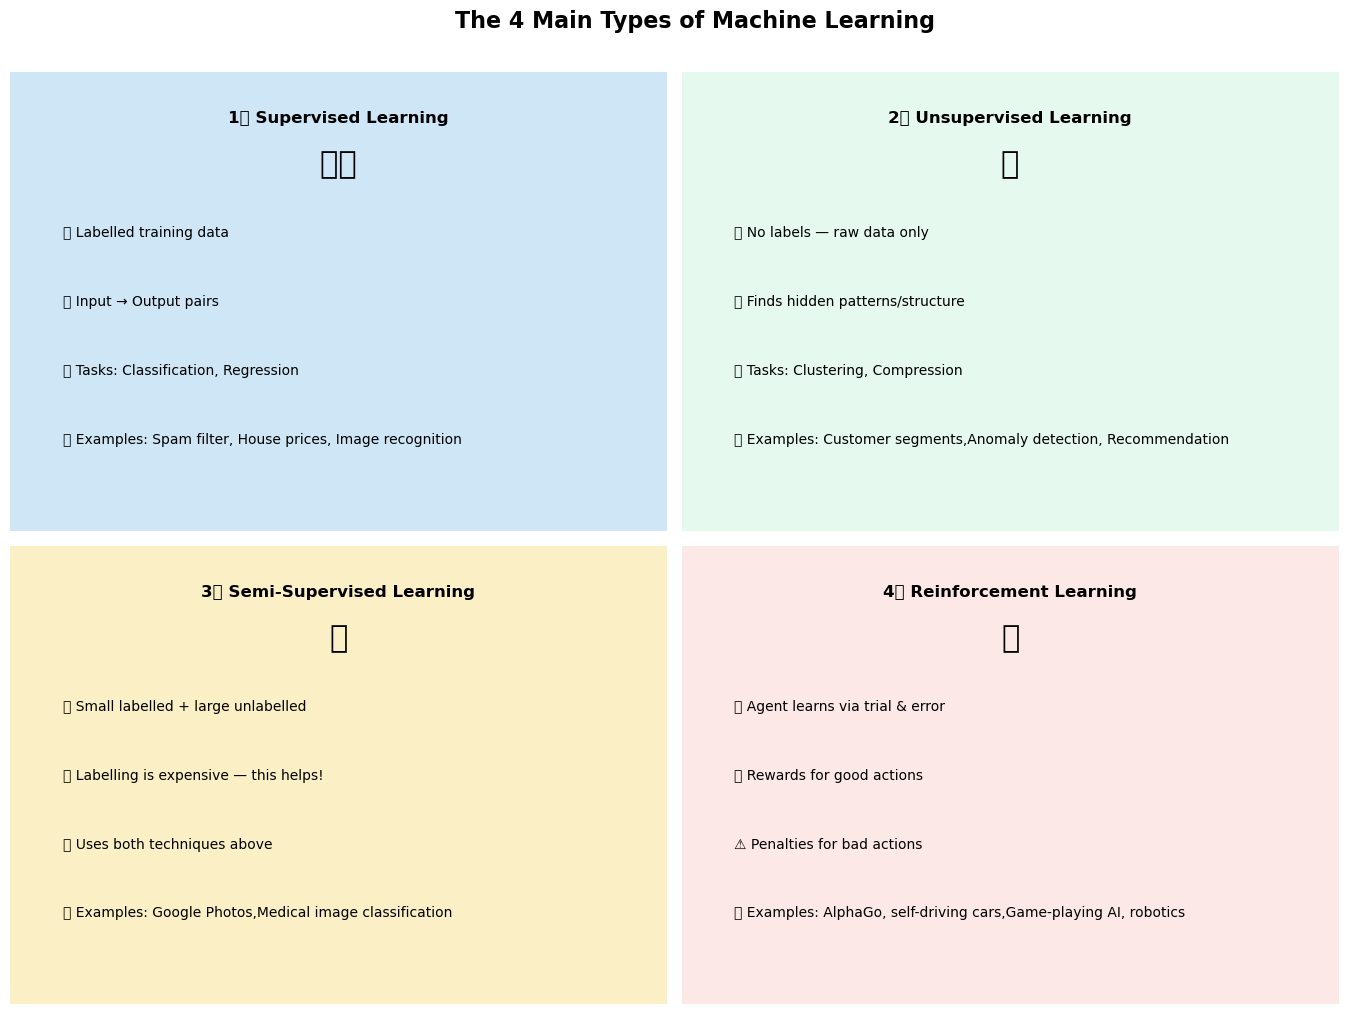

In [13]:
# VISUAL: The 4 Types of ML at a glance
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("The 4 Main Types of Machine Learning", fontsize=16, fontweight='bold', y=1.01)

configs = [
    {
        "ax": axes[0, 0],
        "title": "1️⃣ Supervised Learning",
        "color": "#AED6F1",
        "items": [
            "✅ Labelled training data",
            "📊 Input → Output pairs",
            "🎯 Tasks: Classification, Regression",
            "📌 Examples: Spam filter, House prices, Image recognition",
        ],
        "emoji": "👩‍🏫"
    },
    {
        "ax": axes[0, 1],
        "title": "2️⃣ Unsupervised Learning",
        "color": "#D5F5E3",
        "items": [
            "❌ No labels — raw data only",
            "🔍 Finds hidden patterns/structure",
            "🎯 Tasks: Clustering, Compression",
            "📌 Examples: Customer segments,Anomaly detection, Recommendation",
        ],
        "emoji": "🕵️"
    },
    {
        "ax": axes[1, 0],
        "title": "3️⃣ Semi-Supervised Learning",
        "color": "#F9E79F",
        "items": [
            "🔀 Small labelled + large unlabelled",
            "💰 Labelling is expensive — this helps!",
            "🎯 Uses both techniques above",
            "📌 Examples: Google Photos,Medical image classification",
        ],
        "emoji": "🔀"
    },
    {
        "ax": axes[1, 1],
        "title": "4️⃣ Reinforcement Learning",
        "color": "#FADBD8",
        "items": [
            "🤖 Agent learns via trial & error",
            "🏆 Rewards for good actions",
            "⚠️ Penalties for bad actions",
            "📌 Examples: AlphaGo, self-driving cars,Game-playing AI, robotics",
        ],
        "emoji": "🎮"
    },
]

for cfg in configs:
    ax = cfg["ax"]
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
    ax.add_patch(mpatches.FancyBboxPatch((0.2, 0.2), 9.6, 9.6,
                 boxstyle="round,pad=0.3", fc=cfg["color"], ec='gray', lw=1.5, alpha=0.6))
    ax.text(5, 9, cfg["title"], ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(5, 8, cfg["emoji"], ha='center', va='center', fontsize=22)
    for i, item in enumerate(cfg["items"]):
        ax.text(0.8, 6.5 - i*1.5, item, va='center', fontsize=10)

plt.tight_layout()
plt.savefig("04_ml_types.png", dpi=150, bbox_inches='tight')
plt.show()


## 4. ⚡ Batch Learning vs Online Learning

### Batch Learning (Offline Learning)
- The model is **trained once** on all available data, then deployed
- To update the model → retrain from scratch on new + old data
- **Problem:** Needs lots of resources; data must fit in memory
- **Example:** Monthly model retrain for a recommendation engine

### Online Learning
- The model is **trained incrementally** as new data arrives
- Good for **data streams** (e.g. stock prices, sensor data)
- Key parameter: **learning rate** — how fast to adapt to new data

> 🟨 **Key Takeaway:** Batch = Train once, deploy. Online = Continuously learns from a stream of data.

> ⚠️ **Risk of Online Learning:** If bad data enters the stream, model performance degrades quickly (called *data poisoning*).


## 5. 📐 Instance-Based vs Model-Based Learning

### Instance-Based Learning
- The system **memorises** training examples
- Generalises by comparing new data to known examples using a **similarity measure**
- **Example:** K-Nearest Neighbours (KNN) — "Find the K most similar past examples and use their labels"

### Model-Based Learning
- The system **builds a model** (mathematical function) from training data
- Uses the model to make predictions on new data
- **Example:** Linear Regression — learns a line/equation to predict values

> 🟨 **Key Takeaway:** Instance-based = memory + similarity. Model-based = learns a generalised function.


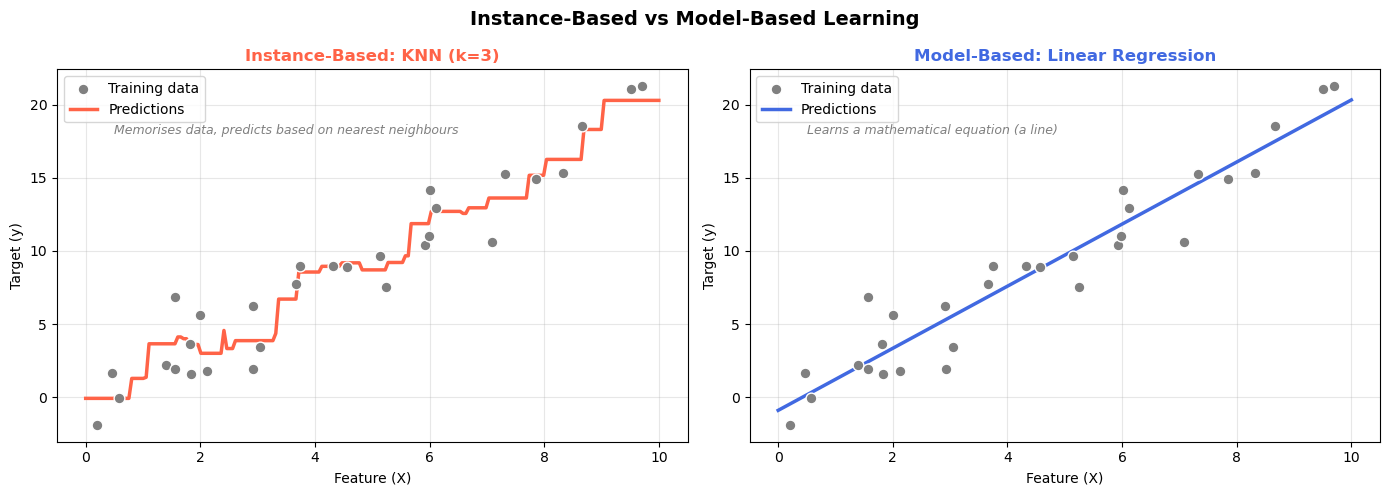

Notice: KNN is jagged (follows data) | Linear Regression is smooth (learned rule)


In [14]:
# VISUAL: Instance-Based (KNN) vs Model-Based (Linear Regression)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

np.random.seed(42)
X_train = np.sort(np.random.uniform(0, 10, 30))
y_train = 2 * X_train + np.random.randn(30) * 2

X_test = np.linspace(0, 10, 200).reshape(-1, 1)
X_train_2d = X_train.reshape(-1, 1)

# Models
knn = KNeighborsRegressor(n_neighbors=3).fit(X_train_2d, y_train)
lr  = LinearRegression().fit(X_train_2d, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Instance-Based vs Model-Based Learning", fontsize=14, fontweight='bold')

for ax, model, title, color, desc in [
    (axes[0], knn, "Instance-Based: KNN (k=3)", "tomato",
     "Memorises data, predicts based on nearest neighbours"),
    (axes[1], lr,  "Model-Based: Linear Regression", "royalblue",
     "Learns a mathematical equation (a line)"),
]:
    y_pred = model.predict(X_test)
    ax.scatter(X_train, y_train, c='gray', edgecolors='white', s=60, 
               zorder=5, label='Training data')
    ax.plot(X_test, y_pred, c=color, lw=2.5, label='Predictions')
    ax.set_title(title, fontsize=12, color=color, fontweight='bold')
    ax.set_xlabel("Feature (X)"); ax.set_ylabel("Target (y)")
    ax.text(0.5, 18, desc, fontsize=9, color='gray', style='italic')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("05_instance_vs_model.png", dpi=150, bbox_inches='tight')
plt.show()
print("Notice: KNN is jagged (follows data) | Linear Regression is smooth (learned rule)")


## 6. ⚠️ Main Challenges of Machine Learning

Two main sources of problems in ML:

### 🗂️ Data Problems

| Problem | What it means | Fix |
|---|---|---|
| **Insufficient data** | Too few training examples | Collect more data |
| **Non-representative data** | Training data doesn't represent real world | Better sampling strategy |
| **Poor quality data** | Noise, errors, missing values | Data cleaning |
| **Irrelevant features** | Too many useless columns | Feature selection/engineering |

### 🤖 Algorithm Problems

| Problem | What it means | Fix |
|---|---|---|
| **Overfitting** | Model memorises training data, fails on new data | Regularisation, more data, simpler model |
| **Underfitting** | Model too simple to learn the pattern | More complex model, better features |

---

### 🔍 Overfitting vs Underfitting — The Most Important Concept!

> 🟦 **Overfitting:** The model performs well on training data but poorly on new, unseen data. It has "memorised" rather than "learned".

> 🟦 **Underfitting:** The model is too simple and can't even capture the pattern in the training data.

> 🟦 **The Sweet Spot:** Just right — good generalisation to new data. This is the goal!


C:\Users\User\AppData\Local\Temp\ipykernel_3140\3496275389.py:38: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3140\3496275389.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_3140\3496275389.py:39: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("06_overfit_underfit.png", dpi=150, bbox_inches='tight')
C:\Users\User\AppData\Local\Temp\ipykernel_3140\3496275389.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("06_overfit_underfit.png", dpi=150, bbox_inches='tight')
c:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\User\anaconda3\Lib\site-p

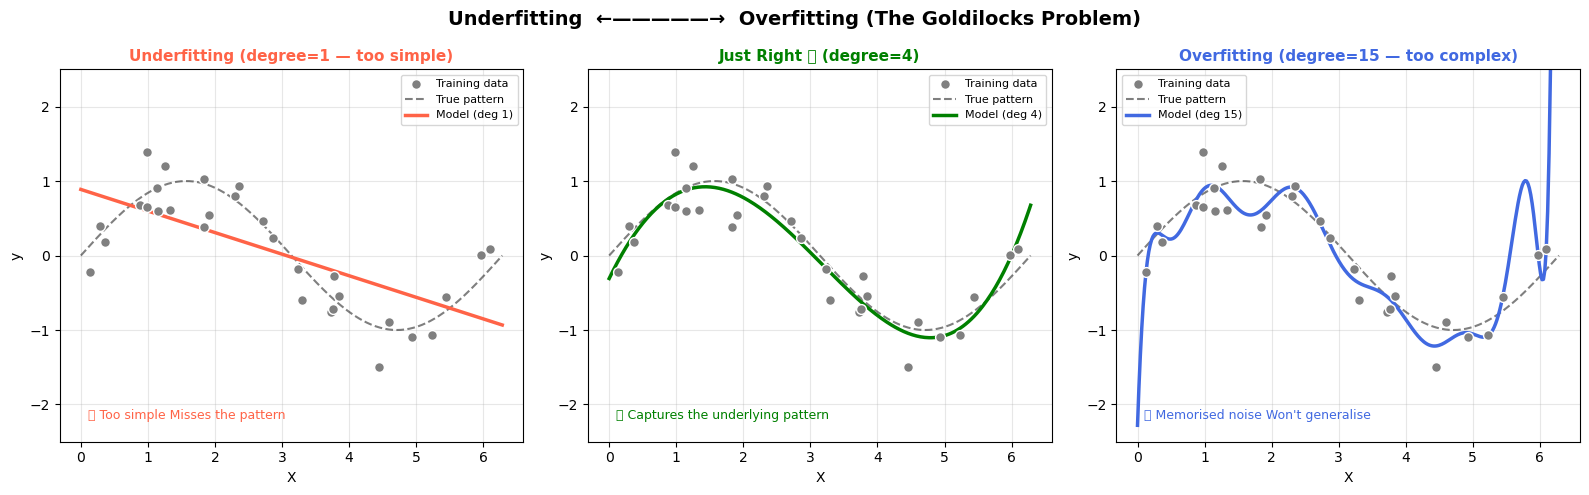

🎯 Goal: degree=4 generalises well. Degree=1 underfits, degree=15 overfits!


In [15]:
# VISUAL: The Bias-Variance Tradeoff / Overfitting vs Underfitting
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

np.random.seed(42)
# True function: y = sin(x) + noise
X = np.sort(np.random.uniform(0, 2*np.pi, 30))
y = np.sin(X) + np.random.randn(30) * 0.3

X_plot = np.linspace(0, 2*np.pi, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Underfitting  ←—————→  Overfitting (The Goldilocks Problem)", 
             fontsize=14, fontweight='bold')

models = [
    (1,  "Underfitting (degree=1 — too simple)", "tomato",    "❌ Too simple Misses the pattern"),(4,  "Just Right ✅ (degree=4)",              "green",     "✅ Captures the underlying pattern"),
(15, "Overfitting (degree=15 — too complex)", "royalblue", "❌ Memorised noise Won't generalise"),
]

for ax, (deg, title, color, note) in zip(axes, models):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(X.reshape(-1, 1), y)
    y_pred = model.predict(X_plot.reshape(-1, 1))
    
    ax.scatter(X, y, c='gray', edgecolors='white', s=50, zorder=5, label='Training data')
    ax.plot(X_plot, np.sin(X_plot), 'k--', lw=1.5, alpha=0.5, label='True pattern')
    ax.plot(X_plot, y_pred, c=color, lw=2.5, label=f'Model (deg {deg})')
    ax.set_title(title, fontsize=11, color=color, fontweight='bold')
    ax.set_ylim(-2.5, 2.5)
    ax.text(0.1, -2.2, note, fontsize=9, color=color)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_xlabel("X"); ax.set_ylabel("y")

plt.tight_layout()
plt.savefig("06_overfit_underfit.png", dpi=150, bbox_inches='tight')
plt.show()
print("🎯 Goal: degree=4 generalises well. Degree=1 underfits, degree=15 overfits!")


## 7. 🧪 Testing and Validating Your Model

### The Train/Test Split

> 🟦 **Key Principle:** Never evaluate your model on data it has already seen during training!

We split data into:
- **Training set** (~80%) → model learns from this
- **Test set** (~20%) → we evaluate *generalisation* here

### Generalisation Error (aka Out-of-Sample Error)

This is the error rate on **new, unseen data**. This is what we actually care about!

- **Low training error + High test error** = Overfitting
- **High training error + High test error** = Underfitting

### Validation Set & Cross-Validation

> 🟦 **Validation Set:** A third split used to tune hyperparameters (settings of the model). We keep the test set *completely locked away* until final evaluation.

> 🟦 **Cross-Validation:** Splits data into k folds — trains k times, each time using a different fold as the validation set. More reliable than a single split.

> 🟨 **Key Takeaway:** Train → Validation → Test is the gold standard workflow. Never use the test set to make decisions!


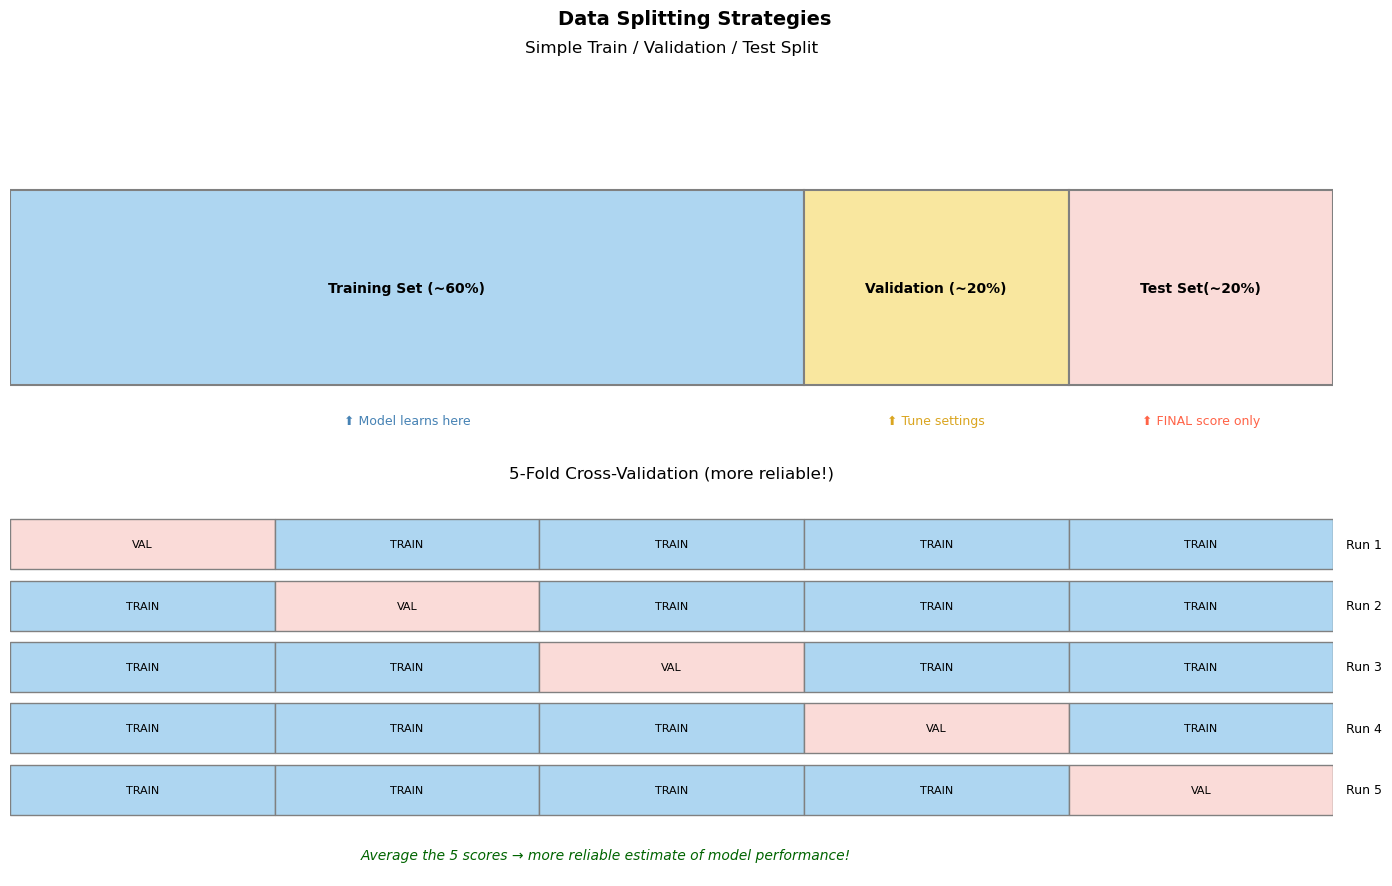

In [16]:
# VISUAL: Train / Validation / Test split + Cross-Validation
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle("Data Splitting Strategies", fontsize=14, fontweight='bold')

# --- Top: Simple Split ---
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 3); ax.axis('off')
ax.set_title("Simple Train / Validation / Test Split", fontsize=12)

split_rects = [
    (0,   6,   "#AED6F1", "Training Set (~60%)"), (6,   2,   "#F9E79F", "Validation (~20%)"), 
    (8,   2,   "#FADBD8", "Test Set(~20%)"),
]
for x, w, color, label in split_rects:
    ax.add_patch(patches.Rectangle((x, 0.5), w, 1.5, fc=color, ec='gray', lw=1.5))
    ax.text(x + w/2, 1.25, label, ha='center', va='center', fontsize=10, fontweight='bold')

ax.text(3, 0.2, "⬆ Model learns here", ha='center', fontsize=9, color='steelblue')
ax.text(7, 0.2, "⬆ Tune settings", ha='center', fontsize=9, color='goldenrod')
ax.text(9, 0.2, "⬆ FINAL score only", ha='center', fontsize=9, color='tomato')

# --- Bottom: K-Fold Cross Validation ---
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 7); ax.axis('off')
ax.set_title("5-Fold Cross-Validation (more reliable!)", fontsize=12)

colors_fold = ["#AED6F1"] * 5
for fold in range(5):
    for j in range(5):
        color = "#FADBD8" if j == fold else "#AED6F1"
        label = "VAL" if j == fold else "TRAIN"
        ax.add_patch(patches.Rectangle((j*2, 5.5 - fold*1.1), 2, 0.9,
                                        fc=color, ec='gray', lw=1))
        ax.text(j*2 + 1, 5.5 - fold*1.1 + 0.45, label, 
                ha='center', va='center', fontsize=8)
    ax.text(10.1, 5.5 - fold*1.1 + 0.45, f"Run {fold+1}", va='center', fontsize=9)

ax.text(4.5, 0.3, "Average the 5 scores → more reliable estimate of model performance!",
        ha='center', fontsize=10, color='darkgreen', style='italic')

plt.tight_layout()
plt.savefig("07_train_test_split.png", dpi=150, bbox_inches='tight')
plt.show()


METHOD 1: Simple Train/Test Split
  Training R² score:    0.9656
  Test R² score:        0.9681

METHOD 2: 5-Fold Cross-Validation
  Fold 1: R² = 0.9692
  Fold 2: R² = 0.9502
  Fold 3: R² = 0.9722
  Fold 4: R² = 0.9611
  Fold 5: R² = 0.9666
Mean R²:  0.9639
  Std Dev:  0.0078  (lower = more consistent)

💡 Cross-validation gives a more reliable estimate because it
   tests on 5 different subsets of data, not just one!


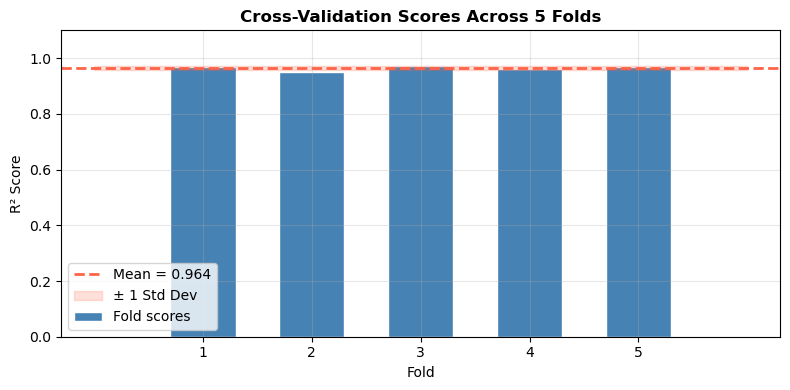

In [18]:
# PRACTICAL: See cross-validation in action with real code
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Create a simple dataset
X, y = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)

# --- Method 1: Simple train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
train_score = model.score(X_train, y_train)
test_score  = model.score(X_test, y_test)

print("=" * 50)
print("METHOD 1: Simple Train/Test Split")
print(f"  Training R² score:    {train_score:.4f}")
print(f"  Test R² score:        {test_score:.4f}")
print()

# --- Method 2: 5-fold cross-validation ---
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print("METHOD 2: 5-Fold Cross-Validation")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: R² = {score:.4f}")
print(f"Mean R²:  {cv_scores.mean():.4f}")
print(f"  Std Dev:  {cv_scores.std():.4f}  (lower = more consistent)")
print()
print("💡 Cross-validation gives a more reliable estimate because it")
print("   tests on 5 different subsets of data, not just one!")

# --- Visualise the variance ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white', width=0.6, label='Fold scores')
ax.axhline(cv_scores.mean(), color='tomato', lw=2, linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
ax.fill_between(range(0, 7), 
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.2, color='tomato', label='± 1 Std Dev')
ax.set_title("Cross-Validation Scores Across 5 Folds", fontsize=12, fontweight='bold')
ax.set_xlabel("Fold"); ax.set_ylabel("R² Score")
ax.set_xticks(range(1, 6)); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig("08_cv_scores.png", dpi=150, bbox_inches='tight')
plt.show()


## 8. 📖 Chapter 1 Key Terminology Glossary

| Term | Simple Definition |
|---|---|
| **Machine Learning** | Systems that learn from data rather than explicit rules |
| **Training Set** | Data the model learns from |
| **Test Set** | Data used to evaluate the final model (never seen during training) |
| **Feature** | An input variable / column in your dataset (e.g. house size) |
| **Label / Target** | The output we're trying to predict (e.g. house price) |
| **Model** | The mathematical function learned from data |
| **Hyperparameter** | A setting of the model chosen before training (e.g. k in KNN) |
| **Training** | The process of fitting a model to data |
| **Inference** | Using a trained model to make predictions on new data |
| **Generalisation** | How well the model performs on unseen data |
| **Overfitting** | Model too complex — memorises training data, fails on new data |
| **Underfitting** | Model too simple — can't learn the pattern |
| **Regularisation** | Technique to reduce overfitting (penalises complexity) |
| **Cross-Validation** | More robust evaluation by training/testing on multiple data splits |
| **R² Score** | How well the model explains variance (1.0 = perfect, 0 = no better than mean) |

---

## 9. 🟨 Chapter 1 Key Takeaways

> 1. **ML = learning patterns from data**, rather than coding explicit rules
> 2. **Supervised learning** needs labels; **unsupervised** finds hidden structure; **reinforcement** learns from rewards
> 3. **Overfitting** (too complex) and **underfitting** (too simple) are the two main modelling pitfalls
> 4. Always **split your data** — the test set must remain *locked away* until final evaluation
> 5. **Cross-validation** gives a more reliable performance estimate than a single train/test split
> 6. **More data** often beats a better algorithm — data quality is everything
> 7. The goal is always **generalisation** — performance on new, unseen data

---
*Next up → Chapter 2: End-to-End Machine Learning Project 🚀*
